In [56]:
%pip install pandas torch transformers deepparse huggingface_hub matplotlib ipympl rdflib sentence_transformers numpy
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [57]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe
Torch version: 2.10.0+cu128, Device: cuda


In [58]:
from huggingface_hub import notebook_login
notebook_login()

In [59]:
from collections import OrderedDict
import pandas as pd
import json

ENTITIES_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "City",
    "State",
    "Country"
]

csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)

ALL_ENTITY_TYPES = [
    "UnitNumber",
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "District",
    "Region",
    "State",
    "Country",
    "PostalCode"
]

FIXED_EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [60]:

from mllms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(ENTITIES_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),

    JsonDictPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n" # TODO Include Kreis (means district)
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s" # TODO Include edge case examples
    "Now annotate the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
]



for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, City, State, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german 

In [61]:
from deepparse_parser import DeepParseParser
from libpostal_client import LibpostalClient
from token_classifiers import TokenClassifierAddressParser
from mllms import LlamaAddressParsingModel, FixedExamples, ZeroShot, SimilarExamples
from itertools import combinations
import time
from pathlib import Path
import numpy as np
from utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "xlm-roberta-large-address-parser", # from https://arxiv.org/abs/2404.05632
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-avg",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "average"},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-max",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "max"},
        "family": "xlm-roberta"
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"),
    ("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct"),
]


example_strategies = [
    ("0shot", ZeroShot()),
    ("fixed3shot", FixedExamples(FIXED_EXAMPLES))
]

for n in range(1, 10 + 1):
    example_strategies.append((f"similar{n}shot", {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=n,
            labels_to_include=ENTITIES_TO_PREDICT,
            device=device
        )
    }))
example_strategies_all_prompts = [example_strategy for example_strategy in example_strategies 
                                  if example_strategy[0] in ["similar5shot"]]

def _make_llama_config(model_id, model_path, prompt_id, example_strategy_id, example_strategy):
        return {
            "name": f"{model_id}-prompt{prompt_id}-{example_strategy_id}",
            "factory": LlamaAddressParsingModel,
            "factory_kargs" : {
                "model_name": model_path,
                "prompt": PROMPTS[prompt_id],
                "example_strategy": example_strategy,
                "device": device
            },
            "family": "Llama"
        }

n_shot_model_configs = []
for model_id, model_name in LLAMA_MODELS:
    for example_strategy_id, example_strategy in example_strategies:
        llama_config = _make_llama_config(model_id, model_name, 2, example_strategy_id, example_strategy)
        if example_strategy_id == "0shot":
            if model_id == "Llama-3-8B":
                n_shot_model_configs.append(llama_config)
        elif isinstance(example_strategy, dict) and example_strategy.get("factory") == SimilarExamples:
            if model_id == "Llama-3-8B":
                n_shot_model_configs.append(llama_config)
            elif example_strategy_id not in ["similar1shot", "similar5shot"]:
                continue
        model_configs.append(llama_config)
    for prompt_id in range(len(PROMPTS)):
        for example_strategy_id, example_strategy in example_strategies_all_prompts:
            if prompt_id == 2 and example_strategy_id in ["similar1shot", "similar5shot"]: continue # Already included above
            model_configs.append(_make_llama_config(model_id, model_name, prompt_id, example_strategy_id, example_strategy))

thresh_similarity_configs = []

for thresh in np.arange(-0.9, 1.0, 0.1):
    thresh_id = f"tresh{thresh:.1f}".replace(".", "p").replace("-", "m")
    example_strategy = {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=10,
            labels_to_include=ENTITIES_TO_PREDICT,
            similarity_threshold=thresh,
            device=device
         )
    }
    llama_config = _make_llama_config("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct", 
                                      2, f"{thresh_id}similarity10shot", example_strategy)
    thresh_similarity_configs.append(llama_config)
    model_configs.append(llama_config)


for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x7fe73215f2e0>, 'family': 'libpostal'}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x7fe73215eac0>, 'family': 'libpostal'}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='cuda')}, 'family': 'd

In [62]:
import traceback

def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if config_name in cached_preds:
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            try:
                print(f"Loading model {config_name}...")
                pargs = config.get("factory_pargs", [])
                kargs = config.get("factory_kargs", {})
                model = config["factory"](*pargs, **kargs)
                print(f"Segmenting addresses...")
                start = time.monotonic()
                preds = model.parse_addresses(dataset["FullAddress"].tolist())
                deltatime = time.monotonic() - start
                if "cleanup" in config:
                    print("Cleaning up model resources...")
                    config["cleanup"](model)
                print("Parsing model responses...")
                if pred_cache_path is not None:
                    cached_preds[config_name] = {
                        "preds": preds,
                        "deltatime": deltatime
                    }
            except Exception as e:
                print(f"Error while processing model {config_name}: {e}")
                traceback.print_exc()
                model_results.append({
                    "error" : len(dataset),
                    "errorRate" : 1.0
                })
                continue
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    if pred_cache_path is not None:
        with open(pred_cache_path, "w") as f:
            json.dump(cached_preds, f)

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])
    return preds_per_config_df, results_df

negative_metrics = ["errorRate"]
skip_columns = ["errorRate"]

def col_best(col):
    if col.name in negative_metrics: return col.min()
    else: return col.max()

overall_best = None

def best_config_per_family(df):
    overall_best_configs = overall_best.index if overall_best is not None else []
    df = df.groupby(by={config["name"]:config.get("family", config["name"]) for config in model_configs}, sort=False).apply(
        lambda group: group.loc[
            [config for config in group.index 
             if config in overall_best_configs or any(
                 col_best(group[col]) == group.at[config, col] 
                 for col in group.columns 
                 if col not in skip_columns
                )]]
    )
    df = df.droplevel(0)
    return df

def bold_best(col):
    return ['font-weight: bold' if v == col_best(col) else '' for v in col]

preds_per_config, model_statistics = eval(bzkopen_val, model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_preds_val.json")
overall_best = best_config_per_family(model_statistics[
    ["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]])
overall_best.style.apply(bold_best)

Loading cached predictions...
Loading model libpostal...
Segmenting addresses...
Cleaning up model resources...
Parsing model responses...
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.7394736842105263, 'precision': 0.6, 'recall': 0.4243421052631579, 'f1': 0.4971098265895954, 'accuracy_with_tol_1': 0.7473684210526316, 'accuracy_with_tol_2': 0.7539473684210526, 'accuracy_with_tol_3': 0.7644736842105263, 'accuracy_with_tol_4': 0.7881578947368421, 'average_levenshtein': 2.031578947368421, 'average_similarity': 0.7702413626939374, 'average_levenshtein_match': 2.4863123993558776, 'average_similarity_match': 0.9426464342148025, 'no_match_rate': 0.18289473684210522, 'deltatime': 0.014451734721660614, 'rate': 10517.76848437293, 'error': 0, 'errorRate': 0.0})
Loading model libpostal-expanded...
Segmenting addresses...
Cleaning up model resources...
Parsing model responses...
Computing metrics...
Results for model libpostal-expanded: OrderedDict({'accuracy': 0.7407

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,0.739474,0.600000,0.424342,0.497110,0.770241,0.000000,10517.768484
libpostal-expanded,0.740789,0.538136,0.417763,0.470370,0.797097,0.000000,4439.059156
deepparse-fasttext,0.475000,0.339416,0.305921,0.321799,0.537354,0.000000,4951.033426
xlm-roberta-large-address-parser-word-avg,0.819737,0.641638,0.618421,0.629816,0.852799,0.000000,521.447337
xlm-roberta-large-address-parser-word-max,0.815789,0.642361,0.608553,0.625000,0.847758,0.000000,555.080700
Llama-3.2-1B-prompt2-0shot,0.443421,0.268245,0.447368,0.335388,0.475139,0.138158,12.917618
Llama-3-8B-prompt2-treshm0p7similarity10shot,0.897368,0.803125,0.845395,0.823718,0.911135,0.013158,2.667714
Llama-3-8B-prompt2-treshm0p1similarity10shot,0.906579,0.798193,0.871711,0.833333,0.923005,0.000000,2.572565


In [63]:
train_preds_per_config, model_train_statistics = eval(bzkopen_train, model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_preds_train.json")
best_config_per_family(model_train_statistics[
    ["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]]).style.apply(bold_best)

Loading cached predictions...
Loading model libpostal...
Segmenting addresses...
Cleaning up model resources...
Parsing model responses...
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.74526588845655, 'precision': 0.5920155793573515, 'recall': 0.4222222222222222, 'f1': 0.4929063640048642, 'accuracy_with_tol_1': 0.7559014267185473, 'accuracy_with_tol_2': 0.7623865110246433, 'accuracy_with_tol_3': 0.7750972762645915, 'accuracy_with_tol_4': 0.791958495460441, 'average_levenshtein': 2.046692607003891, 'average_similarity': 0.7776491918214781, 'average_levenshtein_match': 2.5183530162783274, 'average_similarity_match': 0.9568584853085854, 'no_match_rate': 0.18728923476005188, 'deltatime': 0.04959534853696823, 'rate': 15545.812717200663, 'error': 0, 'errorRate': 0.0})
Loading model libpostal-expanded...
Segmenting addresses...
Cleaning up model resources...
Parsing model responses...
Computing metrics...
Results for model libpostal-expanded: OrderedDict({'accur

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,0.745266,0.592016,0.422222,0.492906,0.777649,0.000000,15545.812717
libpostal-expanded,0.742153,0.533451,0.420833,0.470497,0.789769,0.000000,9085.667065
deepparse-fasttext,0.498054,0.363708,0.321528,0.341320,0.549587,0.000000,4985.400252
xlm-roberta-large-address-parser,0.805707,0.623663,0.647917,0.635559,0.835744,0.000000,588.166414
xlm-roberta-large-address-parser-word-avg,0.814267,0.651163,0.661111,0.656099,0.840891,0.000000,538.912649
xlm-roberta-large-address-parser-word-max,0.812451,0.649897,0.654861,0.652369,0.838960,0.000000,581.009112
Llama-3.2-1B-prompt2-0shot,0.446693,0.252509,0.436806,0.320020,0.477981,0.130999,14.123700
Llama-3-8B-prompt2-treshm0p9similarity10shot,0.929702,0.841875,0.935417,0.886184,0.939466,0.001297,3.129911
Llama-3-8B-prompt2-treshm0p7similarity10shot,0.925811,0.834783,0.933333,0.881311,0.935565,0.000000,2.750648
Llama-3-8B-prompt2-treshm0p3similarity10shot,0.930739,0.845477,0.934722,0.887863,0.939305,0.001297,3.030819


In [64]:
split_dfs = {
    "train" : {
        "stats" : model_train_statistics,
        "preds" : train_preds_per_config
    },
    "val" : {
        "stats" : model_statistics,
        "preds" : preds_per_config
    }
}

In [65]:
best_config_per_family(model_train_statistics[["accuracy", "f1"]].merge(
    model_statistics[["accuracy", "f1"]],
    left_index=True, right_index=True, suffixes=("_train", "_val")
)).style.apply(bold_best)

,accuracy_train,f1_train,accuracy_val,f1_val
libpostal,0.745266,0.492906,0.739474,0.497110
libpostal-expanded,0.742153,0.470497,0.740789,0.470370
deepparse-fasttext,0.498054,0.341320,0.475000,0.321799
xlm-roberta-large-address-parser-word-avg,0.814267,0.656099,0.819737,0.629816
xlm-roberta-large-address-parser-word-max,0.812451,0.652369,0.815789,0.625000
Llama-3.2-1B-prompt2-0shot,0.446693,0.320020,0.443421,0.335388
Llama-3-8B-prompt2-treshm0p7similarity10shot,0.925811,0.881311,0.897368,0.823718
Llama-3-8B-prompt2-treshm0p3similarity10shot,0.930739,0.887863,0.894737,0.820031
Llama-3-8B-prompt2-treshm0p1similarity10shot,0.928664,0.886259,0.906579,0.833333


In [66]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,house,state_district,unit,...,StreetSuffix,Post,Apt,County,HouseNumberAdditional,CityPart,Kreis,HouseNumberAdditionalInfo,HouseNumberExtension,CitySuffix
0,libpostal,"Regensburg, Königstr. 2/I",2/i,königstr.,NaN,NaN,NaN,regensburg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,nibelungenstrasse,NaN,NaN,NaN,nürnberg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,jöhlingen/krs.durlach/baden.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,burlington road manchester,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Llama-3-8B-prompt2-tresh0p9similarity10shot,2114-79 St. Jackson Heights. N.Y. USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Llama-3-8B-prompt2-tresh0p9similarity10shot,Losone CSR,Losone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,Llama-3-8B-prompt2-tresh0p9similarity10shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,Union St.,Brooklyn,N.Y.,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Llama-3-8B-prompt2-tresh0p9similarity10shot,Rum.,Rum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
def look_at_conversation(full_conversation):
    conversation = json.loads(full_conversation)[0]["generated_text"]
    for i, turn in enumerate(conversation):
        print(f"Turn {i} - Role: {turn['role']}")
        print(f"Content:\n{turn['content']}")
        print()

for _, row in preds_per_config[preds_per_config["config_name"] == "Llama-3-8B-prompt2-similar5shot"].sample(5).iterrows():
    look_at_conversation(row["fullConversation"])
    print("-" * 50)

Turn 0 - Role: user
Content:
You are a german archivist handling the digitalization of german documents from the compensation efforts that followed the second world war. Your current task consists of annotating addresses found in the archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. It is essential that you remain loyal to the original text and do not add any information not explictly mentioned in the address. Addresses will most times be written in german, meaning country and city names may be in german. The addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße", "avenue" or its abbreviation "str." and "av." for street.
These terms may occur as a suffix to another word.
Format the output as a JSON object with the component types as keys.
Consider the following examples:
Address: Giessen
```json{"City": "Giessen"}```
Address: Giwataim
```json{}```


In [68]:
n_shot_config_names = [config["name"] for config in n_shot_model_configs]
threshold_config_names = [config["name"] for config in thresh_similarity_configs]
model_statistics_nshots = model_statistics[model_statistics.index.isin(n_shot_config_names)]
train_model_statistics_nshots = model_train_statistics[model_train_statistics.index.isin(n_shot_config_names)]
model_statistics_thresh = model_statistics[model_statistics.index.isin(threshold_config_names)]
train_model_statistics_thresh = model_train_statistics[model_train_statistics.index.isin(threshold_config_names)]

In [69]:
default_cols = ["config_name", "FullAddress"] + ENTITIES_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in ENTITIES_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,City_pred,City_true,State_pred,State_true,Country_pred,Country_true
0,libpostal,"Regensburg, Königstr. 2/I",2/i,2/I,königstr.,Königstr.,NaN,Regensburg,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,8,nibelungenstrasse,Nibelungenstrasse,NaN,Nürnberg,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,Jöhlingen,NaN,Baden,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,8,burlington road manchester,Burlington Road,NaN,Manchester,NaN,NaN,NaN,England
...,...,...,...,...,...,...,...,...,...,...,...,...
9343,Llama-3-8B-prompt2-tresh0p9similarity10shot,2114-79 St. Jackson Heights. N.Y. USA,NaN,2114,NaN,79 St.,NaN,N.Y.,NaN,NaN,NaN,USA
9344,Llama-3-8B-prompt2-tresh0p9similarity10shot,Losone CSR,Losone,NaN,NaN,NaN,NaN,Losone,NaN,NaN,NaN,CSR
9345,Llama-3-8B-prompt2-tresh0p9similarity10shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,1544,Union St.,Union St.,Brooklyn,N.Y.,N.Y.,NaN,NaN,NaN
9346,Llama-3-8B-prompt2-tresh0p9similarity10shot,Rum.,Rum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.


In [70]:

metric = "f1"
best_config_per_family(model_statistics[[metric]])


,f1
libpostal,0.497110
libpostal-expanded,0.470370
deepparse-fasttext,0.321799
xlm-roberta-large-address-parser-word-avg,0.629816
xlm-roberta-large-address-parser-word-max,0.625000
Llama-3.2-1B-prompt2-0shot,0.335388
Llama-3-8B-prompt2-treshm0p7similarity10shot,0.823718
Llama-3-8B-prompt2-treshm0p1similarity10shot,0.833333


In [71]:
from utils import Aggregator
from collections import defaultdict

def get_n_shots(config):
    config_name = config["name"]
    config_prefix = "-".join([part for part in config_name.split("-") if not part.endswith("shot")])
    example_strategy = config.get("factory_kargs", {}).get("example_strategy")
    if isinstance(example_strategy, ZeroShot):
        return 0, config_prefix
    elif isinstance(example_strategy, FixedExamples):
        return len(example_strategy.examples), config_prefix
    elif isinstance(example_strategy, dict):
        if example_strategy.get("factory") == SimilarExamples:
            num_examples = example_strategy.get("factory_kargs", {}).get("num_examples")
            if num_examples is not None:
                return num_examples, config_prefix
    return None, None

config_prefixes = set(get_n_shots(config)[1] for config in n_shot_model_configs)
config_nshots = set(get_n_shots(config)[0] for config in n_shot_model_configs)

metric_per_shot = {
    (split, prefix) : defaultdict(Aggregator) for split in ["train", "val"] for prefix in config_prefixes
}

sim_per_shot = defaultdict(Aggregator)


for config in n_shot_model_configs:
    config_name = config["name"]
    n_shots, config_prefix = get_n_shots(config)
    assert n_shots is not None
    for split in ["train", "val"]:
        stats = split_dfs[split]["stats"]
        preds = split_dfs[split]["preds"]
        preds = preds[preds["config_name"] == config_name]
        metric_per_shot[(split, config_prefix)][n_shots].aggregate_single(stats.at[config_name, metric])
        for meta in preds["___example_metadata"]:
            if isinstance(meta, list):
                sim_per_shot[n_shots].aggregate([hit["score"] for hit in meta])
metric_per_shot = pd.DataFrame(
    data={
        idx : {col : agg.mean for col, agg in col_aggs.items()} 
        for idx, col_aggs in metric_per_shot.items()
    },
    columns=pd.MultiIndex.from_tuples(
        [(split, prefix) for prefix in config_prefixes for split in ["train", "val"]], 
        names=["split", "config_prefix"]
    ))
metric_per_shot.index.name = "n_shots"
if len(set(metric_per_shot.columns.get_level_values("config_prefix"))) != 1:
    for split in metric_per_shot.columns.get_level_values("split").unique():
        metric_per_shot[split, "mean"] = metric_per_shot[split].mean(axis=1)
metric_per_shot.columns = ['_'.join(col).strip('_') for col in metric_per_shot.columns]

sim_per_shot = pd.DataFrame(
    {
        stat : {nshot : getattr(agg, stat) for nshot, agg in sim_per_shot.items()} 
        for stat in ["mean", "max", "min"]
})

<Axes: title={'center': 'f1 per number of examples'}, xlabel='Number of examples', ylabel='f1'>

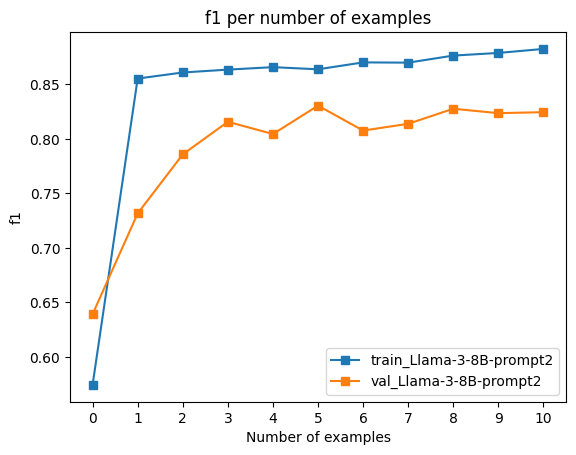

In [72]:
metric_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of examples"
)

<Axes: title={'center': 'Similarity scores per number of examples'}, xlabel='Number of examples', ylabel='Similarity score'>

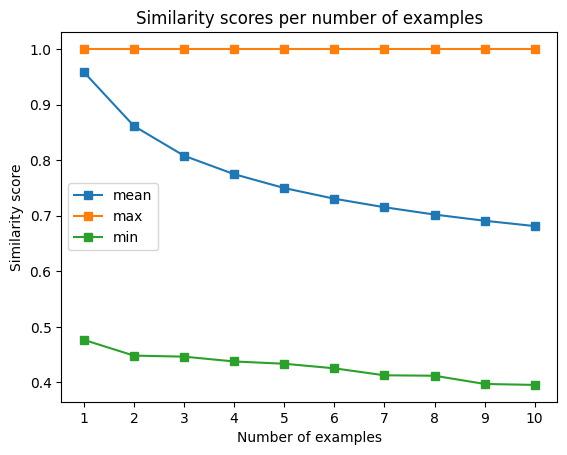

In [73]:
sim_per_shot.plot(
    kind="line", marker="s", xticks=sim_per_shot.index,
    xlabel="Number of examples", ylabel="Similarity score", 
    title=f"Similarity scores per number of examples"
)

In [74]:
def get_threshold(config):
    config_name = config["name"]
    config_prefix = "-".join([part for part in config_name.split("-") if not part.endswith("shot")])
    example_strategy = config.get("factory_kargs", {}).get("example_strategy")
    if isinstance(example_strategy, dict):
        if example_strategy.get("factory") == SimilarExamples:
            threshold = example_strategy.get("factory_kargs", {}).get("similarity_threshold")
            if threshold is not None:
                return threshold, config_prefix
    return None, None

metric_per_thresh = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    [(split, get_threshold(config)[1], config["name"]) 
     for config in thresh_similarity_configs for split in ["train", "val"]],
    names=["split", "config_prefix", "config_name"]
))
count_per_thresh = pd.DataFrame(index=metric_per_thresh.index, columns=metric_per_thresh.columns)


for config in thresh_similarity_configs:
    config_name = config["name"]
    threshold, config_prefix = get_threshold(config)
    assert threshold is not None
    for split in ["train", "val"]:
        stats = split_dfs[split]["stats"]
        preds = split_dfs[split]["preds"]
        metric_per_thresh.at[threshold, (split, config_prefix, config_name)] = stats.at[config_name, metric]
        config_preds = preds[preds["config_name"] == config_name]
        config_example_counts = config_preds["___example_metadata"].apply(lambda meta: sum((1 if hit["included"] else 0) for hit in meta))
        count_per_thresh.at[threshold, (split, config_prefix, config_name)] = config_example_counts.sum()

metric_per_thresh = metric_per_thresh.stack(level="config_name").groupby(level=0).mean()      
metric_per_thresh.index.name = None
if len(set(metric_per_thresh.columns.get_level_values("config_prefix"))) != 1:
    for split in metric_per_thresh.columns.get_level_values("split").unique():
        metric_per_thresh[split, "mean"] = metric_per_thresh[split].mean(axis=1)
metric_per_thresh.columns = ['_'.join(col).strip('_') for col in metric_per_thresh.columns]

<Axes: title={'center': 'f1 per similarity threshold'}, xlabel='Similarity threshold', ylabel='f1'>

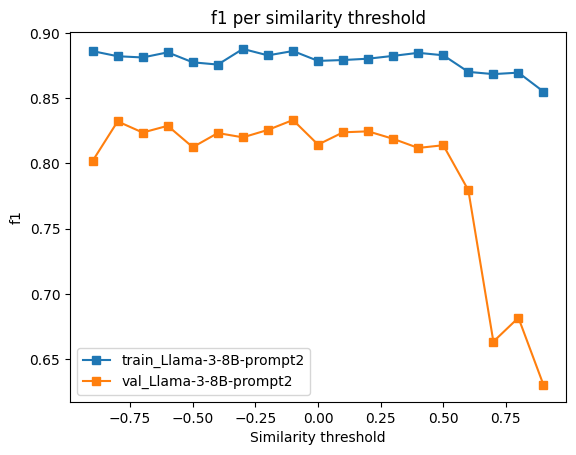

In [75]:
metric_per_thresh.plot(
    kind="line", marker="s",
    xlabel="Similarity threshold", ylabel=metric, 
    title=f"{metric} per similarity threshold"
)

In [76]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=ENTITIES_TO_PREDICT)
for col in ENTITIES_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column = best_config_per_family(metric_per_column)
metric_per_column.style.apply(bold_best)


Per-column f1 scores:


,HouseNumber,StreetName,City,State,Country
libpostal,0.678571,0.529915,0.400000,0.400000,0.466667
libpostal-expanded,0.678571,0.245614,0.454148,0.250000,0.608696
deepparse-bpemb,0.640000,0.027397,0.257813,0.000000,0.169492
deepparse-fasttext,0.568807,0.075758,0.363636,0.000000,0.272727
deepparse-bpemb-attention,0.231884,0.048387,0.009901,0.000000,0.180451
deepparse-fasttext-attention,0.423529,0.045455,0.090498,0.000000,0.231405
xlm-roberta-large-address-parser,0.803419,0.677686,0.462687,0.117647,0.765432
xlm-roberta-large-address-parser-word-avg,0.803419,0.722689,0.505660,0.117647,0.759494
xlm-roberta-large-address-parser-word-max,0.803419,0.728814,0.498084,0.117647,0.734177
Llama-3.2-1B-prompt2-0shot,0.228188,0.388571,0.501901,0.032258,0.222222


<Axes: title={'center': 'Val f1 per number of examples'}, xlabel='Number of examples', ylabel='f1'>

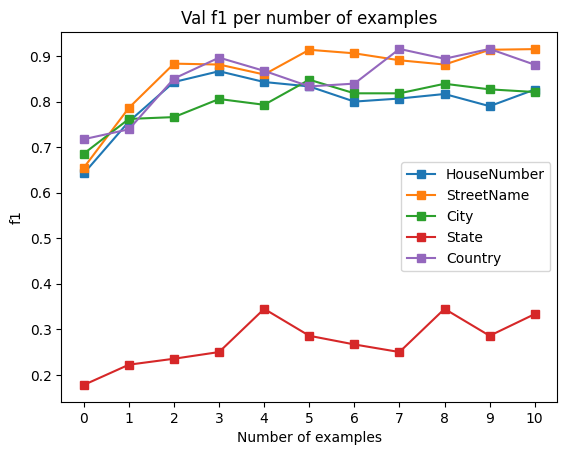

In [77]:
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=ENTITIES_TO_PREDICT
)
for col in ENTITIES_TO_PREDICT:
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_config[preds_per_config["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            n_shots, model_name = get_n_shots(config)
            if n_shots is not None:
                metric_per_column_per_shot.at[(config_name, n_shots), col] = value
        else:
            metric_per_column_per_shot.at[(config_name, 0), col] = pd.NA

metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"Val {metric} per number of examples"
)

In [78]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field = best_config_per_family(metric_per_bzk_field)
metric_per_bzk_field.style.apply(bold_best)

bzk_fields: <StringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
    'VictimCurrentAddress',     'ApplicantBirthPlace',
        'VictimDeathPlace']
Length: 5, dtype: str
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,VictimCurrentAddress,ApplicantBirthPlace,VictimDeathPlace
libpostal,0.500000,0.486486,0.450980,0.530973,0.545455
libpostal-expanded,0.411985,0.536585,0.392157,0.616667,0.800000
deepparse-fasttext,0.241993,0.595745,0.294118,0.397059,0.500000
xlm-roberta-large-address-parser-word-avg,0.594059,0.604651,0.660550,0.671756,0.909091
xlm-roberta-large-address-parser-word-max,0.594059,0.571429,0.666667,0.656250,0.909091
Llama-3.2-1B-prompt2-0shot,0.430168,0.200000,0.360902,0.222222,0.285714
Llama-3-8B-prompt2-similar6shot,0.843750,0.880000,0.696429,0.785714,0.833333
Llama-3-8B-prompt2-similar8shot,0.871473,0.862745,0.696429,0.819444,0.833333
Llama-3-8B-prompt2-similar9shot,0.849057,0.862745,0.698113,0.833333,1.000000
Llama-3-8B-prompt2-similar10shot,0.852665,0.840000,0.743363,0.808219,1.000000


<Axes: title={'center': 'Val f1 per number of examples'}, xlabel='Number of examples', ylabel='f1'>

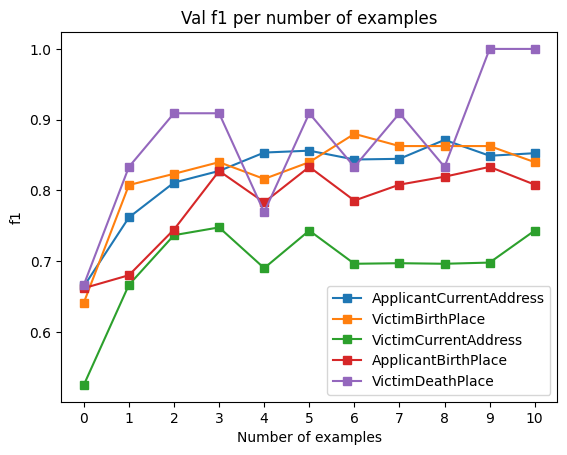

In [79]:
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_config[preds_per_config["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        n_shots, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(config_name, n_shots), field] = value

metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"Val {metric} per number of examples"
)